# Training a U-Net with BiaPy

Here we train our own model because we want something a generic model such as cellpose or stardist is desing for: 
Segment the nuclei, from the **actin** (phalloidin) channel. If that works we can stop staining DNA and use that channel for
a different marker.

We get will run model training first and look at what it did. The details of how it works come
afterwards, once there is something to point at.

The images come from `data_collection_IDR_stardist.ipynb` — you have them as a zip, so you
do not need to run that notebook. U
When running the notebook on your own laptop use the BiaPy kernel (`nlbi26-day3-biapy`) in the instructions.
On Research Cloud you can just select the 'biapy' kernel.

In [2]:
from pathlib import Path
import shutil
import random

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
from IPython.display import Image, display

from skimage.io import imread
from skimage.measure import label as connected_components
from skimage.segmentation import find_boundaries
from scipy.ndimage import distance_transform_edt

## 1. The data

Unzip `training_data` next to this notebook. Two folders with matching file names:
`images/` is the phalloidin channel, `labels/` are the nuclei StarDist found in the DAPI
channel. Open both in the file browser on the left and check that the names match.

In [3]:
DATA = Path('training_data')

image_files = sorted((DATA / 'images').glob('*.tif'))
label_files = sorted((DATA / 'labels').glob('*.tif'))

print(len(image_files), 'images,', len(label_files), 'label images')

100 images, 100 label images


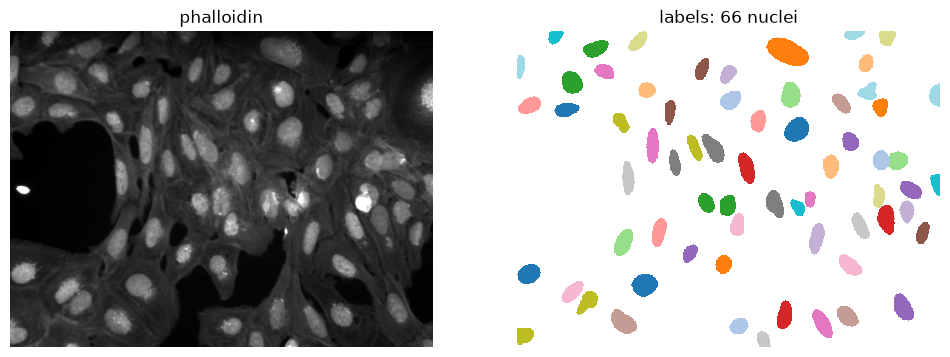

In [4]:
image = imread(DATA / 'images' / '1895787.tif')
labels = imread(DATA / 'labels' / '1895787.tif')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(image, cmap='gray', vmin=np.percentile(image, 1), vmax=np.percentile(image, 99.8))
axes[0].set_title('phalloidin')
axes[1].imshow(np.ma.masked_equal(labels, 0), cmap='tab20', interpolation='nearest')
axes[1].set_title(f'labels: {labels.max()} nuclei')
for ax in axes:
    ax.axis('off')

Nobody checked all 100 label images, so count the nuclei in each one before we train on them.

In [5]:
counts = pd.Series({f.name: imread(f).max() for f in label_files})

print(counts.describe().round(1))
print()
print('empty:', list(counts[counts == 0].index))

count    100.0
mean     107.0
std       38.4
min        0.0
25%       85.8
50%      111.0
75%      135.5
max      173.0
dtype: float64

empty: ['1897201.tif', '1898947.tif']


Two images have no nuclei. They teach the network nothing and they break the scores later
(you cannot ask how many of the nuclei we found when there are none), so we drop them.

## 2. Splitting the data

Three piles:

- **training** — what the network learns from
- **validation** — checked every epoch, to see whether it is still improving or has started
  memorising the training images
- **test** — touched once, at the end. It is the only honest number you get, and the moment
  you use it to pick a setting it stops being one.

Train and test become folders. Validation is not a folder: BiaPy takes a fraction of the
training images.

In [6]:
TEST_FRACTION = 0.2
VALIDATION_FRACTION = 0.2

usable = [f.stem for f in label_files if imread(f).max() > 0]

random.seed(42)          # fixed, so everyone gets the same split
random.shuffle(usable)

n_test = round(len(usable) * TEST_FRACTION)
test_ids = usable[:n_test]
train_ids = usable[n_test:]

print(len(train_ids), 'train,', len(test_ids), 'test')

78 train, 20 test


In [7]:
DATASET = Path('dataset')

# Wipe it first. Otherwise, if you change the split and run this again, images from the old
# split stay behind and a test image quietly ends up in the training set as well.
if DATASET.exists():
    shutil.rmtree(DATASET)

for split, ids in [('train', train_ids), ('test', test_ids)]:
    for kind in ('images', 'labels'):
        folder = DATASET / split / kind
        folder.mkdir(parents=True, exist_ok=True)
        for image_id in ids:
            shutil.copy(DATA / kind / f'{image_id}.tif', folder / f'{image_id}.tif')

print(len(list((DATASET / 'train' / 'images').glob('*.tif'))), 'files in train')
print(len(list((DATASET / 'test' / 'images').glob('*.tif'))), 'files in test')

78 files in train
20 files in test


Open `dataset/` in the file browser. Check that `train/images/` and `train/labels/` hold the
same names, and that nothing appears in both `train/` and `test/`.

We split randomly, which is fine here: different wells, different fields. When would that be
wrong? Think about frames of a time lapse, slices through one organoid, or five fields from
each of four patients.

## 3. The settings

BiaPy reads a YAML file. We take the template BiaPy publishes for 2D instance segmentation,
change a few settings from Python, and write it back out.

In [8]:
patch_size = 256     # the network trains on crops of this size, not whole images
epochs = 20          # one epoch is one pass over the training images
batch_size = 8       # crops through the network at once

# Start with the simplest thing we can ask of the network: for every pixel, is this a
# nucleus or not. Section 7 is about what else you could ask it.
data_channels = ['F']
job_name = 'run1_foreground'     # each run gets its own name, so nothing is overwritten
run_id = 1

output_path = 'training_output'

In [11]:
from urllib.request import urlretrieve

template = Path('2d_instance_segmentation.yaml')
if not template.exists():
    urlretrieve(
        'https://raw.githubusercontent.com/BiaPyX/BiaPy/v3.7.1/templates/'
        'instance_segmentation/2d_instance_segmentation.yaml',
        template,
    )

print(template.read_text())

# BiaPy version: 3.7.1

SYSTEM:
    NUM_CPUS: -1

PROBLEM:
    TYPE: INSTANCE_SEG
    NDIM: 2D
    INSTANCE_SEG:
        DATA_CHANNELS: BC
  
DATA: 
    PATCH_SIZE: (256, 256, 1)  
    TRAIN:                                                                                                              
        PATH: /path/to/data
        GT_PATH: /path/to/data
        IN_MEMORY: True
    VAL:
        SPLIT_TRAIN: 0.1
    TEST:                                                                                                               
        PATH: /path/to/data
        GT_PATH: /path/to/data
        IN_MEMORY: True
        LOAD_GT: True
        PADDING: (32,32)

AUGMENTOR:
    ENABLE: True
    RANDOM_ROT: True
    VFLIP: True
    HFLIP: True

MODEL:
    ARCHITECTURE: unet
    LOAD_CHECKPOINT: False

TRAIN:
    ENABLE: True
    OPTIMIZER: ADAMW
    LR: 1.E-4
    BATCH_SIZE: 8
    EPOCHS: 100
    PATIENCE: 20

# Loss function
LOSS:
    CLASS_REBALANCE: True # give the same weight to all 

Read that file into a dictionary, change what we need, save it under a new name. The
template stays untouched so you can always start over.

In [12]:
config = yaml.safe_load(template.read_text())

# what the network has to predict
config['PROBLEM']['INSTANCE_SEG']['DATA_CHANNELS'] = data_channels

# where the data is
config['DATA']['TRAIN']['PATH'] = 'dataset/train/images'
config['DATA']['TRAIN']['GT_PATH'] = 'dataset/train/labels'
config['DATA']['TEST']['PATH'] = 'dataset/test/images'
config['DATA']['TEST']['GT_PATH'] = 'dataset/test/labels'

# validation comes out of the training images
config['DATA']['VAL']['FROM_TRAIN'] = True
config['DATA']['VAL']['SPLIT_TRAIN'] = VALIDATION_FRACTION

# PATCH_SIZE has to be a string, that is how BiaPy reads it
config['DATA']['PATCH_SIZE'] = f'({patch_size}, {patch_size}, 1)'
config['TRAIN']['EPOCHS'] = epochs
config['TRAIN']['BATCH_SIZE'] = batch_size

run_config = Path('2d_instance_segmentation_config.yaml')
run_config.write_text(yaml.safe_dump(config, sort_keys=False))

print(run_config.read_text())

SYSTEM:
  NUM_CPUS: -1
PROBLEM:
  TYPE: INSTANCE_SEG
  NDIM: 2D
  INSTANCE_SEG:
    DATA_CHANNELS:
    - F
DATA:
  PATCH_SIZE: (256, 256, 1)
  TRAIN:
    PATH: dataset/train/images
    GT_PATH: dataset/train/labels
    IN_MEMORY: true
  VAL:
    SPLIT_TRAIN: 0.2
    FROM_TRAIN: true
  TEST:
    PATH: dataset/test/images
    GT_PATH: dataset/test/labels
    IN_MEMORY: true
    LOAD_GT: true
    PADDING: (32,32)
AUGMENTOR:
  ENABLE: true
  RANDOM_ROT: true
  VFLIP: true
  HFLIP: true
MODEL:
  ARCHITECTURE: unet
  LOAD_CHECKPOINT: false
TRAIN:
  ENABLE: true
  OPTIMIZER: ADAMW
  LR: 0.0001
  BATCH_SIZE: 8
  EPOCHS: 20
  PATIENCE: 20
LOSS:
  CLASS_REBALANCE: true
TEST:
  ENABLE: true
  AUGMENTATION: false
  FULL_IMG: false



## 4. Train

A few minutes on a GPU. Watch the `loss` and `IoU` on the per-epoch lines.

In [13]:
from biapy import BiaPy

biapy = BiaPy(config=str(run_config), result_dir=output_path, name=job_name,
              run_id=run_id, gpu='0')
biapy.run_job()

Date     : 2026-09-18 10:22:05
Arguments: Namespace(config='2d_instance_segmentation_config.yaml', result_dir='training_output', name='run1_foreground', run_id=1, gpu='0', world_size=1, local_rank=-1, dist_on_itp=False, dist_url='env://', dist_backend='nccl')
Job      : run1_foreground_1
BiaPy    : 3.6.8
Python   : 3.12.14 (main, Sep  2 2026, 23:27:36) [GCC 15.3.0]
PyTorch  : 2.5.1
The following changes were made in order to adapt the input configuration:
Not using distributed mode
[10:22:06.017955] Configuration details:
[10:22:06.018002] AUGMENTOR:
  AFFINE_MODE: reflect
  AUG_NUM_SAMPLES: 10
  AUG_SAMPLES: True
  BRIGHTNESS: False
  BRIGHTNESS_FACTOR: (-0.1, 0.1)
  CBLUR_DOWN_RANGE: (2, 8)
  CBLUR_INSIDE: True
  CBLUR_SIZE: (0.2, 0.4)
  CHANNEL_SHUFFLE: False
  CMIX_SIZE: (0.2, 0.4)
  CNOISE_NB_ITERATIONS: (1, 3)
  CNOISE_SCALE: (0.05, 0.1)
  CNOISE_SIZE: (0.2, 0.4)
  CONTRAST: False
  CONTRAST_FACTOR: (-0.1, 0.1)
  COUT_APPLY_TO_MASK: False
  COUT_CVAL: 0.0
  COUT_NB_ITERATIONS: (1

100%|██████████| 78/78 [00:01<00:00, 52.02it/s]


[10:22:08.382362] You select to create ['F'] channels from given instance labels and no file is detected in dataset/test/labels_F.erosion-0.dilation-0 . So let's prepare the data. This process will be done just once!
[10:22:08.382828] Creating Y_test channels . . .


100%|██████████| 20/20 [00:00<00:00, 57.21it/s]


[10:22:08.733256] DATA.TRAIN.GT_PATH changed from dataset/train/labels to dataset/train/labels_F.erosion-0.dilation-0
[10:22:08.733302] DATA.TEST.GT_PATH changed from dataset/test/labels to dataset/test/labels_F.erosion-0.dilation-0
[10:22:08.734091] ##########################
[10:22:08.734119] #   LOAD TRAINING DATA   #
[10:22:08.734132] ##########################
[10:22:08.734194] ### LOAD ###
[10:22:08.734521] Gathering raw images for training data . . .
[10:22:08.842587] Gathering labels for training data . . .
[10:22:08.950912] Checking training raw and label images' shapes . . .
[10:22:08.951617] Creating validation data from train . . .
[10:22:09.003814] Raw images chosen for training: ['dataset/train/images/1895787.tif', 'dataset/train/images/1895824.tif', 'dataset/train/images/1895860.tif', 'dataset/train/images/1895878.tif', 'dataset/train/images/1895887.tif', 'dataset/train/images/1895905.tif', 'dataset/train/images/1895914.tif', 'dataset/train/images/1895995.tif', 'dataset/

...

[10:23:14.036047] ### MERGE-OV-CROP ###
[10:23:14.036091] Merging (12, 256, 256, 1) images into (1, 520, 696, 1) with overlapping . . .
[10:23:14.036107] Minimum overlap selected: (0, 0)
[10:23:14.036121] Padding: (32, 32)
[10:23:14.036368] Real overlapping (%): (0.125, 0.14583333333333334)
[10:23:14.036395] Real overlapping (pixels): (24.0, 28.0)
[10:23:14.036409] (4, 3) patches per (x,y) axis
[10:23:14.039003] **** New data shape is: (1, 520, 696, 1)
[10:23:14.039033] ### END MERGE-OV-CROP ###
[10:23:14.039059] ### MERGE-OV-CROP ###
[10:23:14.039074] Merging (12, 256, 256, 1) images into (1, 520, 696, 1) with overlapping . . .
[10:23:14.039088] Minimum overlap selected: (0, 0)
[10:23:14.039101] Padding: (32, 32)
[10:23:14.039221] Real overlapping (%): (0.125, 0.14583333333333334)
[10:23:14.039243] Real overlapping (pixels): (24.0, 28.0)
[10:23:14.039257] (4, 3) patches per (x,y) axis
[10:23:14.040634] **** New data shape is: (1, 520, 696, 1)
[10:23:14.040659] ### END MERGE-OV-CROP ##

[10:23:14.059742] Creating instances with watershed . . .
[10:23:14.074229] Thresholds used: {'seed': [0.47709518671035767], 'growth_mask': [0.23854759335517883]}
[10:23:14.095680] Saving (1, 1, 520, 696, 1) data as .tif in folder: training_output/run1_foreground/results/run1_foreground_1/per_image_instances


[10:23:14.101367] Calculating matching stats . . .
[10:23:14.101432] Its respective image seems to be: dataset/test/labels/1898902.tif


[10:23:14.235679] DatasetMatching: {'criterion': 'iou', 'thresh': 0.3, 'fp': np.int64(39), 'tp': np.int64(66), 'fn': np.int64(12), 'precision': np.float64(0.6285714285714286), 'recall': np.float64(0.8461538461538461), 'accuracy': np.float64(0.5641025641025641), 'f1': np.float64(0.7213114754098361), 'n_true': 78, 'n_pred': 105, 'mean_true_score': np.float32(0.61957806), 'mean_matched_score': np.float64(0.7322285970052084), 'panoptic_quality': np.float64(0.528164889643101)}
[10:23:14.237538] DatasetMatching: {'criterion': 'iou', 'thresh': 0.5, 'fp': np.int64(43), 'tp': np.int64(62), 'fn': np.int64(16), 'precision': np.float64(0.5904761904761905), 'recall': np.float64(0.7948717948717948), 'accuracy': np.float64(0.512396694214876), 'f1': np.float64(0.6775956284153005), 'n_true': 78, 'n_pred': 105, 'mean_true_score': np.float32(0.59831136), 'mean_matched_score': np.float64(0.7527142801592427), 'panoptic_quality': np.float64(0.5100359056816727)}
[10:23:14.239192] DatasetMatching: {'criterion

<Figure size 640x480 with 0 Axes>

In [14]:
results = Path(output_path) / job_name / 'results' / f'{job_name}_{run_id}'

for item in sorted(results.iterdir()):
    print(item.name)

[10:23:14.252012] aug
[10:23:14.252083] charts
[10:23:14.252099] instance_associations
[10:23:14.252112] per_image
[10:23:14.252125] per_image_instances
[10:23:14.252138] tensorboard
[10:23:14.252150] test_F_instance_channels
[10:23:14.252163] test_results_metrics.csv
[10:23:14.252176] train_F_instance_channels


## 5. Check the training graphs

BiaPy automatically plots the graphs and saves them in `charts/`.

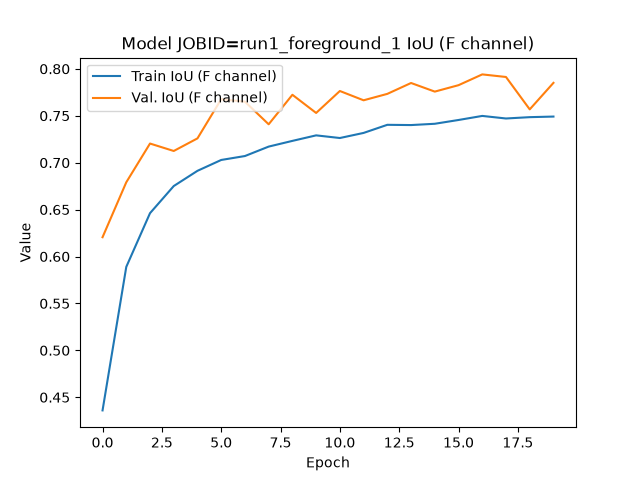

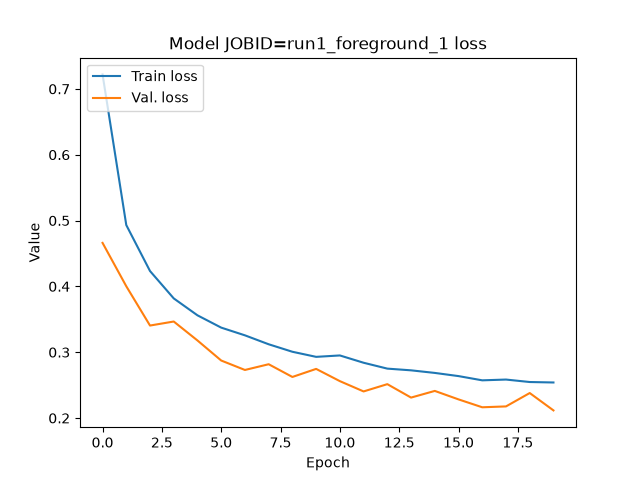

In [15]:
for chart in sorted((results / 'charts').glob('*.png')):
    display(Image(str(chart)))

The loss is how wrong the network is, so lower is good
Th difference between the training and validation curves is important to monitor.

If the loss is still going down for both training and validation at the last epoch it  means we can train longer. 
If it flat for a while it means it has learned what it can. 
Training loss dropping while validation loss rises means it is starts memorising the training images, we need to stop earlier, augment more, or get more data. 

Look at your own two curves and decide which of those is the case, before changing
anything.

The IoU plot is the overlap between what the network predicts and the target, per channel.

## 6. What does it predict?

`TEST.ENABLE` was on, so BiaPy already ran the model on the 20 test images.

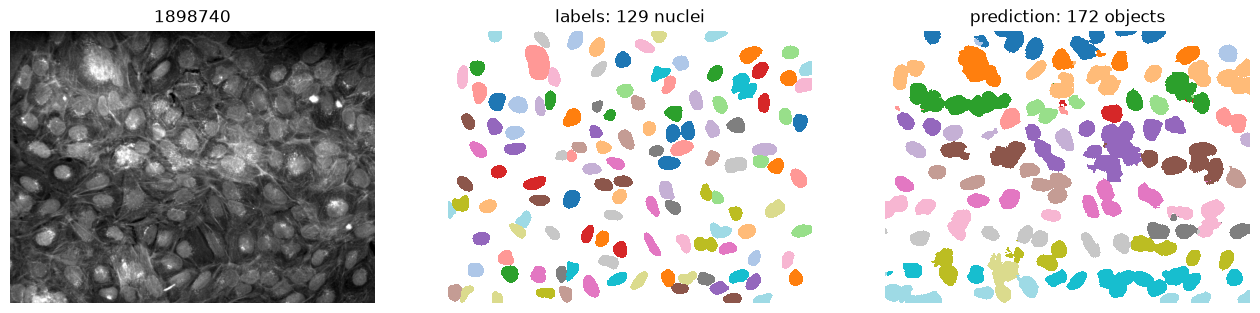

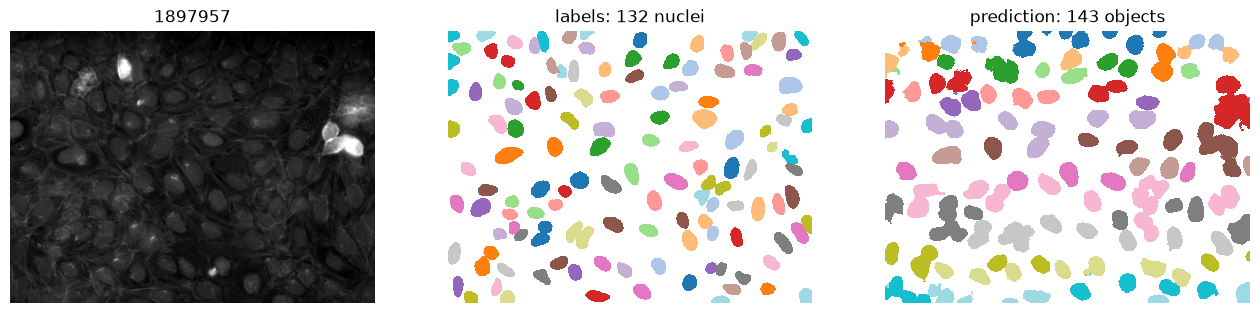

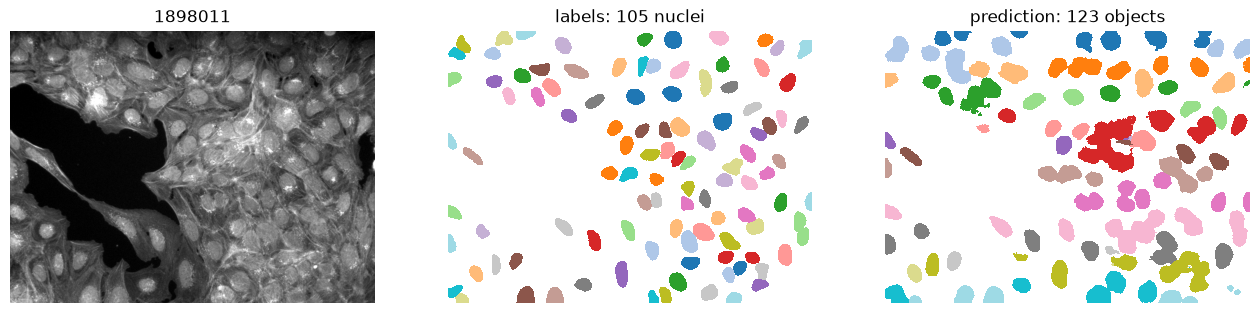

In [16]:
predictions = results / 'per_image_instances'

for image_id in test_ids[:3]:
    test_image = imread(DATASET / 'test' / 'images' / f'{image_id}.tif')
    test_labels = imread(DATASET / 'test' / 'labels' / f'{image_id}.tif')
    predicted = imread(predictions / f'{image_id}.tif')

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    axes[0].imshow(test_image, cmap='gray',
                   vmin=np.percentile(test_image, 1), vmax=np.percentile(test_image, 99.8))
    axes[0].set_title(image_id)
    axes[1].imshow(np.ma.masked_equal(test_labels, 0), cmap='tab20', interpolation='nearest')
    axes[1].set_title(f'labels: {test_labels.max()} nuclei')
    axes[2].imshow(np.ma.masked_equal(predicted, 0), cmap='tab20', interpolation='nearest')
    axes[2].set_title(f'prediction: {predicted.max()} objects')
    for ax in axes:
        ax.axis('off')
    plt.show()

Look at a dense patch and look for two nuclei that got one colour. So it means it is segmented as one object.
At `results / test_results_metrics.csv` biapy already collects different metrics from the test data.

The simplest score: how many objects. If your question is how many cells are in
a well, this may be all you need.

In [ ]:
counts = scores[['file', '0.5 TH n_true', '0.5 TH n_pred']].copy()
counts.columns = ['image', 'nuclei in the labels', 'objects found']

print(counts.head(10))
print()
print(counts.sum(numeric_only=True))

[10:51:26.507529]          image  nuclei in the labels  objects found
0  1895788.tif                   137            156
1  1895923.tif                   135            150
2  1895950.tif                   107            119
3  1896103.tif                     2            108
4  1896670.tif                    35             77
5  1896787.tif                   131            149
6  1896841.tif                   112            141
7  1897129.tif                    39             66
8  1897615.tif                    68             86
9  1897687.tif                    83            114
[10:51:26.508615] 
[10:51:26.508947] nuclei in the labels    1950
objects found           2433
dtype: int64


But a count says nothing about *where* the objects are. To decide whether a predicted object
*is* the same as a labelled one we can compare their overlapping pixels: **intersection over union**, 
the pixels they share divided by the pixels they cover together. 1.0 is identical, 0.5 is a reasonable overlap,
0.0 is no overlap at all.

Text(0.5, 0.98, 'IoU = 1451 / 2431 = 0.60')

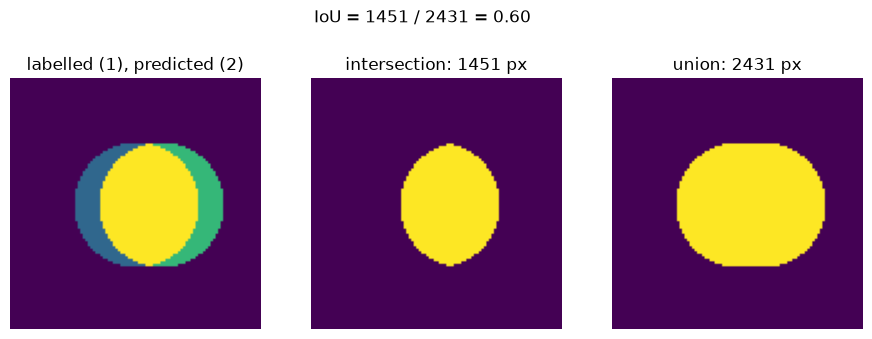

In [22]:
yy, xx = np.mgrid[:100, :100]
labelled = (yy - 50) ** 2 + (xx - 50) ** 2 < 25 ** 2
predicted = (yy - 50) ** 2 + (xx - 60) ** 2 < 25 ** 2

intersection = (labelled & predicted).sum()
union = (labelled | predicted).sum()

fig, axes = plt.subplots(1, 3, figsize=(11, 4))
for ax, img, title in zip(
        axes,
        [labelled + 2 * predicted, labelled & predicted, labelled | predicted],
        ['labelled (1), predicted (2)', f'intersection: {intersection} px', f'union: {union} px']):
    ax.imshow(img, cmap='viridis')
    ax.set_title(title)
    ax.axis('off')

fig.suptitle(f'IoU = {intersection} / {union} = {intersection / union:.2f}')

**Try it:** move the predicted circle closer (`xx - 60` → `xx - 50`) or make it bigger
(`25 ** 2` → `35 ** 2`) and re-run. How far off can a prediction be and still reach 0.5?

Two objects count as the same when their IoU is above a threshold — 0.5 by convention.
Then every object is one of three things:

- **TP** — a predicted object that matches a labelled one
- **FP** — a predicted object that matches nothing: invented
- **FN** — a labelled object that nothing matches: missed

**precision** = TP / (TP + FP), of what it found, how much is real.
**recall** = TP / (TP + FN), of what is there, how much did it find.
**F1** combines the two. These are the `0.5 TH` columns.

In [25]:
at_05 = scores[['file', '0.5 TH tp', '0.5 TH fp', '0.5 TH fn',
                '0.5 TH precision', '0.5 TH recall', '0.5 TH f1',
                '0.5 TH mean_matched_score']].copy()
at_05.columns = ['image', 'TP', 'FP', 'FN', 'precision', 'recall', 'F1', 'mean matched IoU']

print(at_05.round(2).head(10))
print()
print(at_05.mean(numeric_only=True).round(2))

[10:52:16.690587]          image  TP   FP  FN  precision  recall    F1  mean matched IoU
0  1895788.tif  61   95  76       0.39    0.45  0.42              0.70
1  1895923.tif  75   75  60       0.50    0.56  0.53              0.72
2  1895950.tif  70   49  37       0.59    0.65  0.62              0.77
3  1896103.tif   0  108   2       0.00    0.00  0.00              0.00
4  1896670.tif  31   46   4       0.40    0.89  0.55              0.75
5  1896787.tif  87   62  44       0.58    0.66  0.62              0.76
6  1896841.tif  77   64  35       0.55    0.69  0.61              0.73
7  1897129.tif  32   34   7       0.48    0.82  0.61              0.80
8  1897615.tif  53   33  15       0.62    0.78  0.69              0.76
9  1897687.tif  73   41  10       0.64    0.88  0.74              0.74
[10:52:16.692837] 
[10:52:16.693326] TP                  60.15
FP                  61.50
FN                  37.35
precision            0.51
recall               0.63
F1                   0.56
mean mat

Which is lower, precision or recall? Go back to the pictures above — what does that look
like in the image?

`mean matched IoU` is the average overlap of the objects that did match. A model can have a
good F1 and a mediocre matched IoU. What kind of mistake is that?

In [31]:
# the same F1, at three levels of strictness
scores[['0.3 TH f1', '0.5 TH f1', '0.75 TH f1']].mean().round(2)

0.3 TH f1     0.64
0.5 TH f1     0.56
0.75 TH f1    0.29
dtype: float64

An F1 that holds up at 0.3 but collapses at 0.75 means the model finds the right nuclei with
sloppy outlines. Which of those matters depends on your question: counting cells needs the
first, measuring nuclear size needs the second.

## 7. How to improve the segmentation

Back to the nuclei that shared a colour.

A U-Net takes an image and returns an image. It cannot output "nucleus 17" — the numbers in
the label image are arbitrary, and nothing tells the network that this blob should be 17 and
the next one 18. So BiaPy turns the labels into target images the network *can* learn, and
rebuilds the objects from the prediction afterwards. Those targets are the **data channels**
we set in section 3, and `['F']` was the simplest of them.

## 8. Run 2: add the contour iton the training

In [33]:
config['PROBLEM']['INSTANCE_SEG']['DATA_CHANNELS'] = ['F', 'C']
job_name = 'run2_foreground_contour'

run_config.write_text(yaml.safe_dump(config, sort_keys=False))

print(config['PROBLEM']['INSTANCE_SEG']['DATA_CHANNELS'], '->', job_name)

[11:09:39.376389] ['F', 'C'] -> run2_foreground_contour


In [34]:
biapy = BiaPy(config=str(run_config), result_dir=output_path, name=job_name,
              run_id=run_id, gpu='0')
biapy.run_job()

[11:09:40.630250] Date     : 2026-09-18 11:09:40
[11:09:40.630347] Arguments: Namespace(config='2d_instance_segmentation_config.yaml', result_dir='training_output', name='run2_foreground_contour', run_id=1, gpu='0', world_size=1, local_rank=-1, dist_on_itp=False, dist_url='env://', dist_backend='nccl')
[11:09:40.630365] Job      : run2_foreground_contour_1
[11:09:40.630382] BiaPy    : 3.6.8
[11:09:40.630397] Python   : 3.12.14 (main, Sep  2 2026, 23:27:36) [GCC 15.3.0]
[11:09:40.630414] PyTorch  : 2.5.1
[11:09:40.635597] The following changes were made in order to adapt the input configuration:
[11:09:40.638682] Not using distributed mode
[11:09:40.641769] Configuration details:
[11:09:40.641800] AUGMENTOR:
  AFFINE_MODE: reflect
  AUG_NUM_SAMPLES: 10
  AUG_SAMPLES: True
  BRIGHTNESS: False
  BRIGHTNESS_FACTOR: (-0.1, 0.1)
  CBLUR_DOWN_RANGE: (2, 8)
  CBLUR_INSIDE: True
  CBLUR_SIZE: (0.2, 0.4)
  CHANNEL_SHUFFLE: False
  CMIX_SIZE: (0.2, 0.4)
  CNOISE_NB_ITERATIONS: (1, 3)
  CNOISE_SCA

100%|██████████| 78/78 [00:03<00:00, 24.63it/s]


[11:09:43.814523] You select to create ['F', 'C'] channels from given instance labels and no file is detected in dataset/test/labels_F.erosion-0.dilation-0_C.mode-thick . So let's prepare the data. This process will be done just once!
[11:09:43.815069] Creating Y_test channels . . .


100%|██████████| 20/20 [00:00<00:00, 26.29it/s]


[11:09:44.576942] DATA.TRAIN.GT_PATH changed from dataset/train/labels to dataset/train/labels_F.erosion-0.dilation-0_C.mode-thick
[11:09:44.576993] DATA.TEST.GT_PATH changed from dataset/test/labels to dataset/test/labels_F.erosion-0.dilation-0_C.mode-thick
[11:09:44.580533] ##########################
[11:09:44.580568] #   LOAD TRAINING DATA   #
[11:09:44.580583] ##########################
[11:09:44.580648] ### LOAD ###
[11:09:44.580980] Gathering raw images for training data . . .
[11:09:44.692960] Gathering labels for training data . . .
[11:09:45.000351] Checking training raw and label images' shapes . . .
[11:09:45.001323] Creating validation data from train . . .
[11:09:45.039120] Raw images chosen for training: ['dataset/train/images/1895787.tif', 'dataset/train/images/1895824.tif', 'dataset/train/images/1895860.tif', 'dataset/train/images/1895878.tif', 'dataset/train/images/1895887.tif', 'dataset/train/images/1895905.tif', 'dataset/train/images/1895914.tif', 'dataset/train/imag

...

[11:10:51.451884] ### MERGE-OV-CROP ###
[11:10:51.451943] Merging (12, 256, 256, 2) images into (1, 520, 696, 2) with overlapping . . .
[11:10:51.451959] Minimum overlap selected: (0, 0)
[11:10:51.451973] Padding: (32, 32)
[11:10:51.452665] Real overlapping (%): (0.125, 0.14583333333333334)
[11:10:51.452700] Real overlapping (pixels): (24.0, 28.0)
[11:10:51.452716] (4, 3) patches per (x,y) axis
[11:10:51.462493] **** New data shape is: (1, 520, 696, 2)
[11:10:51.462546] ### END MERGE-OV-CROP ###
[11:10:51.462581] ### MERGE-OV-CROP ###
[11:10:51.462598] Merging (12, 256, 256, 1) images into (1, 520, 696, 1) with overlapping . . .
[11:10:51.462612] Minimum overlap selected: (0, 0)
[11:10:51.462626] Padding: (32, 32)
[11:10:51.462879] Real overlapping (%): (0.125, 0.14583333333333334)
[11:10:51.462916] Real overlapping (pixels): (24.0, 28.0)
[11:10:51.462932] (4, 3) patches per (x,y) axis
[11:10:51.465093] **** New data shape is: (1, 520, 696, 1)
[11:10:51.465139] ### END MERGE-OV-CROP ##

[11:10:51.511625] Creating instances with watershed . . .
[11:10:51.531628] Thresholds used: {'seed': [0.48734986782073975, 0.47067201137542725], 'growth_mask': [0.24367493391036987]}
[11:10:51.554607] Saving (1, 1, 520, 696, 1) data as .tif in folder: training_output/run2_foreground_contour/results/run2_foreground_contour_1/per_image_instances


[11:10:51.561724] Calculating matching stats . . .
[11:10:51.561920] Its respective image seems to be: dataset/test/labels/1898902.tif


[11:10:51.703699] DatasetMatching: {'criterion': 'iou', 'thresh': 0.3, 'fp': np.int64(55), 'tp': np.int64(77), 'fn': np.int64(1), 'precision': np.float64(0.5833333333333334), 'recall': np.float64(0.9871794871794872), 'accuracy': np.float64(0.5789473684210527), 'f1': np.float64(0.7333333333333333), 'n_true': 78, 'n_pred': 132, 'mean_true_score': np.float32(0.72199744), 'mean_matched_score': np.float64(0.7313740222485035), 'panoptic_quality': np.float64(0.5363409496489026)}
[11:10:51.705640] DatasetMatching: {'criterion': 'iou', 'thresh': 0.5, 'fp': np.int64(56), 'tp': np.int64(76), 'fn': np.int64(2), 'precision': np.float64(0.5757575757575758), 'recall': np.float64(0.9743589743589743), 'accuracy': np.float64(0.5671641791044776), 'f1': np.float64(0.7238095238095238), 'n_true': 78, 'n_pred': 132, 'mean_true_score': np.float32(0.7159109), 'mean_matched_score': np.float64(0.734750697487279), 'panoptic_quality': np.float64(0.5318195524669829)}
[11:10:51.707427] DatasetMatching: {'criterion':

<Figure size 640x480 with 0 Axes>

In [35]:
run1 = Path(output_path) / 'run1_foreground' / 'results' / 'run1_foreground_1'
run2 = Path(output_path) / 'run2_foreground_contour' / 'results' / 'run2_foreground_contour_1'

scores1 = pd.read_csv(run1 / 'test_results_metrics.csv')
scores2 = pd.read_csv(run2 / 'test_results_metrics.csv')

interesting = ['0.5 TH n_true', '0.5 TH n_pred', '0.5 TH tp', '0.5 TH fp', '0.5 TH fn',
               '0.5 TH precision', '0.5 TH recall', '0.5 TH f1', '0.5 TH mean_matched_score']

pd.DataFrame({
    'F': scores1[interesting].mean(),
    'F + C': scores2[interesting].mean(),
}).round(2)

,F,F + C
0.5 TH n_true,97.50,97.50
0.5 TH n_pred,121.65,168.95
0.5 TH tp,60.15,90.45
0.5 TH fp,61.50,78.50
0.5 TH fn,37.35,7.05
0.5 TH precision,0.51,0.55
0.5 TH recall,0.63,0.89
0.5 TH f1,0.56,0.68
0.5 TH mean_matched_score,0.70,0.69


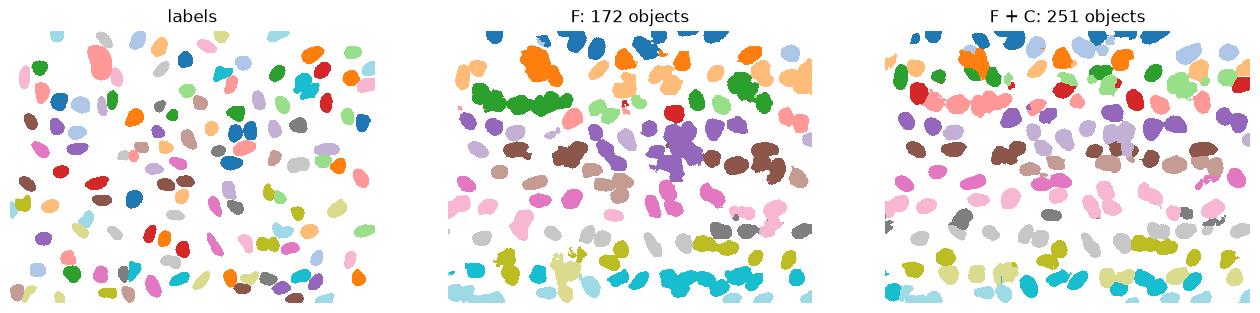

In [37]:
image_id = test_ids[0]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(np.ma.masked_equal(imread(DATASET / 'test' / 'labels' / f'{image_id}.tif'), 0),
               cmap='tab20', interpolation='nearest')
axes[0].set_title('labels')

for ax, run, name in zip(axes[1:], [run1, run2], ['F', 'F + C']):
    predicted = imread(run / 'per_image_instances' / f'{image_id}.tif')
    ax.imshow(np.ma.masked_equal(predicted, 0), cmap='tab20', interpolation='nearest')
    ax.set_title(f'{name}: {predicted.max()} objects')

for ax in axes:
    ax.axis('off')

Did the contour change the *number* of objects, their *outlines*, or both — and which column
tells you that? Did FN go down? That is where the merged nuclei were hiding.

Both runs got 20 epochs. Two channels is a harder job than one, so open run 2's charts and
see whether it had finished learning.

## 9. If you have time

Each of these is one line, then re-run the config cell, the training cell and the scoring
cells. Give every run its own `job_name`. They take as long as the runs above, so pick one
or two.

```python
config['PROBLEM']['INSTANCE_SEG']['DATA_CHANNELS'] = ['F', 'D']   # distance instead of contour
config['TRAIN']['EPOCHS'] = 60                                    # if the loss was still falling
config['AUGMENTOR']['ENABLE'] = False                             # it is on in the template
config['DATA']['PATCH_SIZE'] = '(128, 128, 1)'                    # smaller crops, less context
config['MODEL']['ARCHITECTURE'] = 'resunet'                       # a different network
```

The last one is what people try first and it is rarely where the gain is. Compare it with
what the contour channel did.

And the question worth asking before any of them: train on 20, 40 and all 78 images
(`train_ids = train_ids[:20]`, then re-run the copy cell) and plot F1 against the number of
training images. If that curve is still rising, annotating more images beats every setting
on this page.